# Logistic Regression (로지스틱 회귀)
: 이진 분류 문제를 해결하는 데 주로 사용되는 머신러닝 모델이며 출력 값이 0과 1 사이의 확률로 나타나도록 변환

- 시그모이드 함수 : z값을 0과 1 사이의 값으로 변환하는 함수, 확률로 제한(선형회귀 모델의 출려값은 무한한 범위를 가짐)


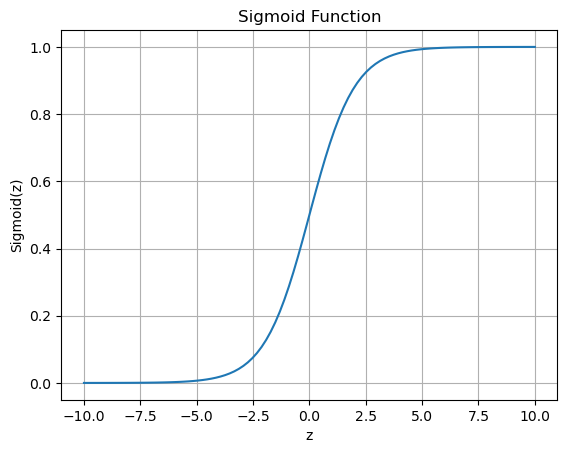

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 함수 정의
def sigmoid(z) : 
    return 1 / (1 + np.exp(-z))

# 값 생성
z = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z)

# 그래프 그리기
plt.plot(z, sigmoid_values)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.grid()
plt.show()
          

In [5]:
## 모델 생성 코드
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분리
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델
from sklearn.metrics import accuracy_score, confusion_matrix # 평가 지표

In [6]:
## 1. 데이터 로드
path = 'C:/juehyeon/aice_test/materials/datasets/'
data = pd.read_csv(path + 'heart.csv')
data.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
## 2. 입 / 출력 분리 
## output 열이 심장병 여부 
X = data.drop('output', axis = 1) # 독립변수 : output 열 제외
y = data['output'] # 종속변수 : output

In [8]:
## 3. 학습용 / 테스트용 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [10]:
## 4. 모델 생성 및 학습
model = LogisticRegression(max_iter = 1000) # 로지스틱 회귀 모델 생성 (반복 횟수 : 1000)
model.fit(X_train, y_train) # 학습 데이터로 모델 학습

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
## 5. 테스트 데이터로 예측 수행
y_pred = model.predict(X_test) # 학습된 모델로 테스트 데이터 예측

In [12]:
## 6. 모델 평가
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [14]:
print("Accuray : ", accuracy)
print("Confusion Matrix : \n", conf_matrix)

Accuray :  0.8852459016393442
Confusion Matrix : 
 [[25  4]
 [ 3 29]]


[모델 평가 관련 내용, 결과해석] 
- accuracy_score : 정확도 예측
- confusion_matrix(혼동 행렬) : 모델의 예측 결과를 상세히 보여줌
  [[TN, FP], [FN,TP]] 형식으로 나타냄 
  - True Positive(TP) : 심장병이 있는 데이터를 맞게 예측
  - True Negative(NP) : 심장병이 없는 데이터를 맞게 예측
  - False Positive(FP) : 심장병이 없는데 있다고 예측(거짓양성)
  - False Negative(FN) : 심장병이 있는데 없다고 예측(거짓음성)

In [16]:
## 다양한 분류모델 평가 코드
from sklearn.metrics import classification_report

In [18]:
# 정밀도, 재현율, F1 Score 
print("Classification Report: \n", classification_report(y_test, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



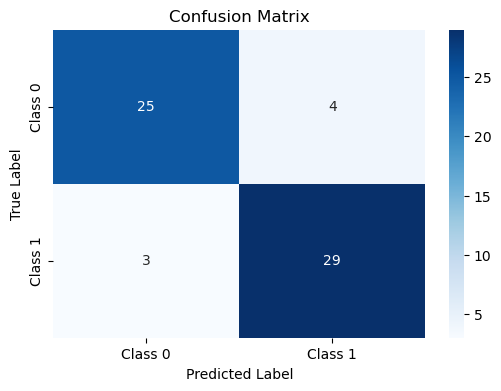

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 혼동 행렬 시각화
plt.figure(figsize = (6,4))
sns.heatmap(conf_matrix, annot = True, fmt= "d", cmap = "Blues", xticklabels=["Class 0", "Class 1"], yticklabels = ["Class 0", "Class 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()